In [1]:
from world import World

world = World(100, 100)

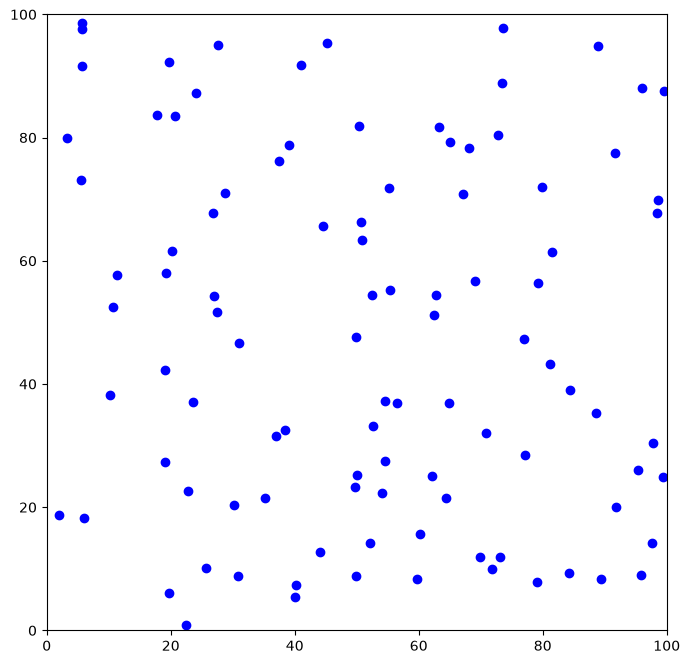

In [2]:
world.add_prey(number=100)
#world.add_predator(number=5)

import matplotlib.pyplot as plt

# plot the world with the preys and predators
plt.figure(figsize=(8, 8))
plt.xlim(0, world.width)
plt.ylim(0, world.height)

for prey in world.preys:
    plt.scatter(prey.x, prey.y, c=world.color_prey)
for predator in world.predators:
    plt.scatter(predator.x, predator.y, c=world.color_predator)
plt.show()

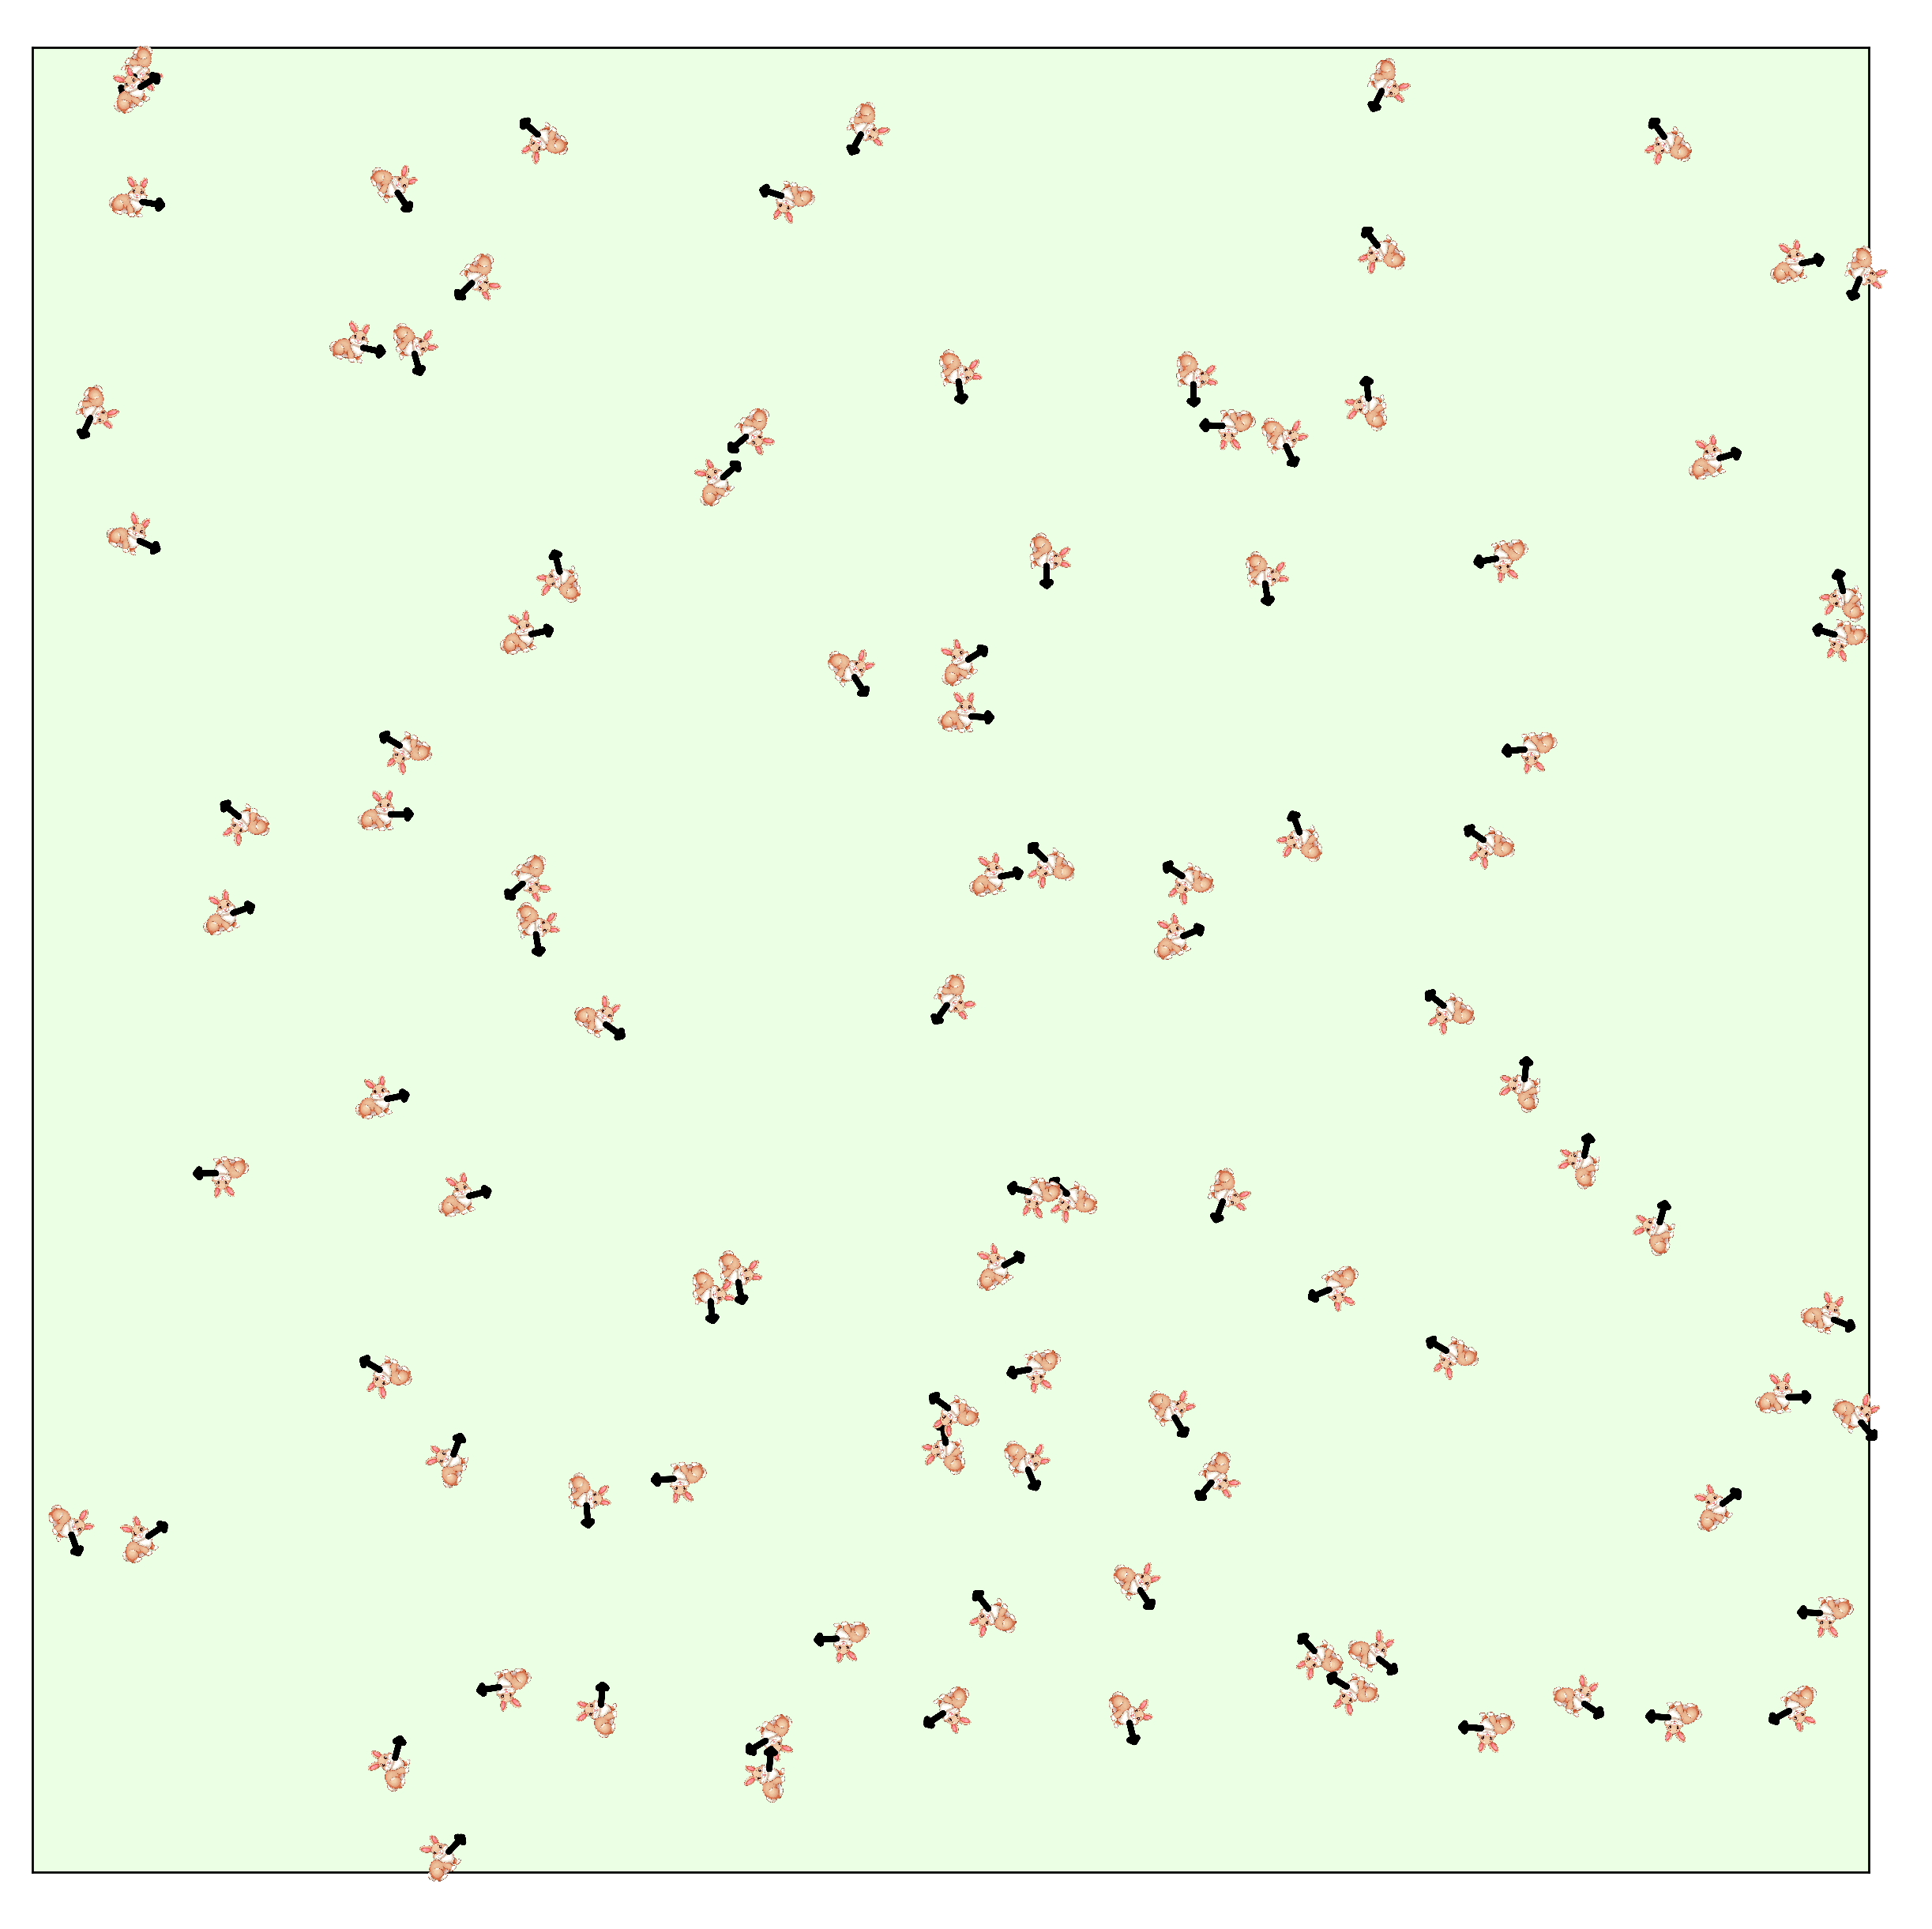

In [3]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np


# Loading the images with PIL
hare_img = Image.open("./images/hare.png")
fox_img = Image.open("./images/fox.png")


plt.figure(figsize=(12, 12), dpi=250)
plt.xlim(0, world.width)
plt.ylim(0, world.height)

# initialization of the axes
ax = plt.gca()

# color of the background
ax.set_facecolor("#ebffe4")

# Hide the axes
ax.set_xticks([])
ax.set_yticks([])

for prey in world.preys:
    # Conversion in degree
    direction = prey.direction*180/np.pi  
    # Rotation of the image
    rotated_img = hare_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    hare_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        hare_icon,
        (prey.x, prey.y),
        frameon=False
    )

    ax.add_artist(ab)


for predator in world.predators:

    direction = predator.direction*180/np.pi

    rotated_img = fox_img.rotate(
        -direction,
        resample=Image.Resampling.BICUBIC,
        expand=True
    )

    fox_icon = OffsetImage(
        np.array(rotated_img),
        zoom=0.05
    )

    ab = AnnotationBbox(
        fox_icon,
        (predator.x, predator.y),
        frameon=False
    )

    ax.add_artist(ab)


plt.show()

In [4]:
N = 10

dict_step = {}

for t in range(N):
    print(f"Step {t}")
    dict_step[t] = world.return_dict()

    # Update the world
    world.step()

Step 0


AttributeError: property 'energy' of 'Prey' object has no setter

In [ ]:
ergthyju

NameError: name 'ergthyju' is not defined

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import numpy as np



hare_img = Image.open("./images/hare.png")
fox_img = Image.open("./images/fox.png")


for t, dict_agent in dict_step.items():
    
    plt.figure(figsize=(12, 12), dpi=250)
    plt.xlim(0, world.width)
    plt.ylim(0, world.height)

    ax = plt.gca()

    ax.set_facecolor("#ebffe4")

    ax.set_xticks([])
    ax.set_yticks([])
    
    for prey in dict_agent["preys"]:
        direction = prey[2]*180/np.pi
        rotated_img = hare_img.rotate(
            direction,
            resample=Image.Resampling.BICUBIC,
            expand=True
        )

        hare_icon = OffsetImage(
            np.array(rotated_img),
            zoom=0.05
        )

        ab = AnnotationBbox(
            hare_icon,
            (prey[0], prey[1]),
            frameon=False
        )

        ax.add_artist(ab)

    for predator in dict_agent["predators"]:
        direction = predator[2]*180/np.pi
        rotated_img = fox_img.rotate(
            direction,
            resample=Image.Resampling.BICUBIC,
            expand=True
        )

        fox_icon = OffsetImage(
            np.array(rotated_img),
            zoom=0.05
        )

        ab = AnnotationBbox(
            fox_icon,
            (predator[0], predator[1]),
            frameon=False
        )

        ax.add_artist(ab)

    plt.title(f"Step {t}", fontsize=20)

    plt.savefig(f"./plot/world_{t}.png")
    plt.close()

In [ ]:
# Creation of a gif from the images
import imageio

images = []
for t in range(N):
    images.append(imageio.imread(f"./plot/world_{t}.png"))

imageio.mimsave("./plot/world.gif", images, fps=2)

/tmp/ipykernel_23031/1930615873.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(f"./plot/world_{t}.png"))
